# 07 — RSU World Map (Fig 1)

Generates `../writing/fig1_map.png` — global distribution of 53 RSUs.

- Points coloured by altitude (blue → red continuous scale)
- Coffee RSUs (RSU-17, 18, 27, 47, 48): open circle overlay
- Grass-fed butter RSUs (RSU-36, 37, 42, 46, 51, 52, 53): triangle overlay
- Base map: Natural Earth 110m via geopandas

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import geopandas as gpd
import warnings
warnings.filterwarnings('ignore')

from rsu_loader import load_all_rsus

rsus = load_all_rsus()

# Build coordinate table
rows = []
for r in rsus:
    rows.append({
        'region_id': r.region_id,
        'name': r.name,
        'lat': r.coordinates.lat,
        'lon': r.coordinates.lon,
        'altitude_m': getattr(r.coordinates, 'altitude_m', 0) or 0,
    })

rsu_df = pd.DataFrame(rows)
print(f'{len(rsu_df)} RSUs loaded')
print(rsu_df[['region_id', 'name', 'lat', 'lon', 'altitude_m']].to_string())

/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


65 RSUs loaded
   region_id                                                             name     lat      lon  altitude_m
0     RSU-01                                                   Boreal Finland  64.500   26.000         150
1     RSU-02                                                    Boreal Canada  54.000 -100.000         400
2     RSU-03                                                   Siberian Taiga  62.000  105.000         200
3     RSU-04                                          Atlantic Western Europe  47.000    2.500         100
4     RSU-05                                                   Central Europe  51.000   10.000         200
5     RSU-06                                             East Asian Temperate  35.000  115.000          50
6     RSU-07                                           North American Prairie  41.000  -97.000         600
7     RSU-08                                     West African Transition Zone   7.500   -1.500         300
8     RSU-09          

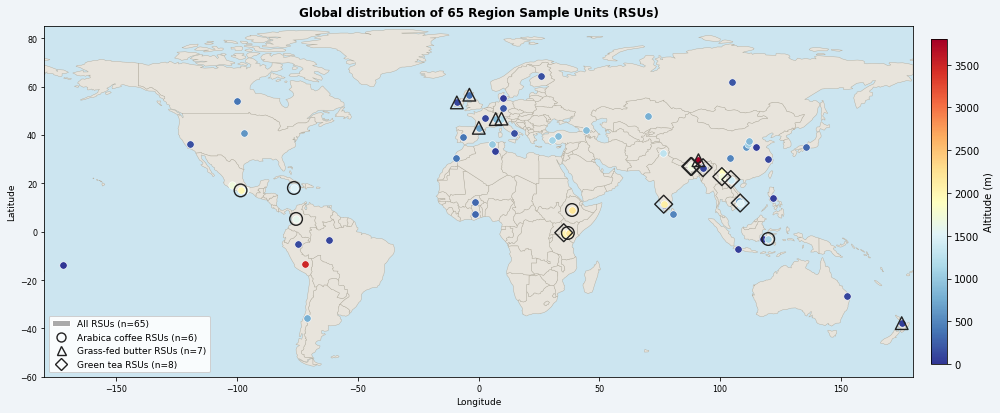

Saved → ../writing/fig1_map.png


In [2]:
# RSU groups to highlight
COFFEE_RSUS  = {'RSU-17', 'RSU-18', 'RSU-27', 'RSU-47', 'RSU-48', 'RSU-54'}
TEA_RSUS     = {'RSU-20', 'RSU-21', 'RSU-56', 'RSU-57', 'RSU-58', 'RSU-59', 'RSU-60', 'RSU-61'}
BUTTER_RSUS  = {'RSU-36', 'RSU-37', 'RSU-42', 'RSU-46', 'RSU-51', 'RSU-52', 'RSU-53'}

# Altitude colour scale
ALT_VMIN, ALT_VMAX = 0, 3800
cmap = plt.cm.RdYlBu_r  # blue (low) → red (high)
norm = mcolors.Normalize(vmin=ALT_VMIN, vmax=ALT_VMAX)

# Load Natural Earth base map
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#f0f4f8')
ax.set_facecolor('#cce5f0')

# Base map — land
world.plot(ax=ax, color='#e8e4dc', edgecolor='#b0a898', linewidth=0.4, zorder=1)

# All RSU points — coloured by altitude
for _, row in rsu_df.iterrows():
    rid = row['region_id']
    color = cmap(norm(row['altitude_m']))
    ax.scatter(row['lon'], row['lat'], color=color, s=55, zorder=3,
               edgecolors='white', linewidths=0.6)

# Coffee overlay — open black circle
for _, row in rsu_df[rsu_df['region_id'].isin(COFFEE_RSUS)].iterrows():
    ax.scatter(row['lon'], row['lat'], color='none', s=160, zorder=4,
               edgecolors='#222222', linewidths=1.4, marker='o')

# Butter overlay — open black triangle
for _, row in rsu_df[rsu_df['region_id'].isin(BUTTER_RSUS)].iterrows():
    ax.scatter(row['lon'], row['lat'], color='none', s=160, zorder=4,
               edgecolors='#222222', linewidths=1.4, marker='^')

# Tea overlay — open black diamond
for _, row in rsu_df[rsu_df['region_id'].isin(TEA_RSUS)].iterrows():
    ax.scatter(row['lon'], row['lat'], color='none', s=160, zorder=4,
               edgecolors='#222222', linewidths=1.4, marker='D')

# Colourbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical',
                    fraction=0.018, pad=0.02, shrink=0.75)
cbar.set_label('Altitude (m)', fontsize=10)
cbar.set_ticks([0, 500, 1000, 1500, 2000, 2500, 3000, 3500])

# Legend
n_total = len(rsu_df)
legend_handles = [
    mpatches.Patch(facecolor='#aaaaaa', edgecolor='white', label=f'All RSUs (n={n_total})'),
    plt.Line2D([0], [0], marker='o', color='none', markeredgecolor='#222222',
               markeredgewidth=1.4, markersize=9, label=f'Arabica coffee RSUs (n={len(COFFEE_RSUS & set(rsu_df.region_id))})'),
    plt.Line2D([0], [0], marker='^', color='none', markeredgecolor='#222222',
               markeredgewidth=1.4, markersize=9, label=f'Grass-fed butter RSUs (n={len(BUTTER_RSUS & set(rsu_df.region_id))})'),
    plt.Line2D([0], [0], marker='D', color='none', markeredgecolor='#222222',
               markeredgewidth=1.4, markersize=9, label=f'Green tea RSUs (n={len(TEA_RSUS & set(rsu_df.region_id))})'),
]
ax.legend(handles=legend_handles, loc='lower left', fontsize=9,
          framealpha=0.9, edgecolor='#cccccc')

ax.set_xlim(-180, 180)
ax.set_ylim(-60, 85)
ax.set_xlabel('Longitude', fontsize=9)
ax.set_ylabel('Latitude', fontsize=9)
ax.set_title(f'Global distribution of {n_total} Region Sample Units (RSUs)',
             fontsize=12, fontweight='bold', pad=10)
ax.tick_params(labelsize=8)

plt.tight_layout()
path = '../writing/fig1_map.png'
fig.savefig(path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved → {path}')